In [33]:
import torch
from torchsummary import summary
import matplotlib.pyplot as plt
from tqdm import tqdm

In [34]:
import h5py

def load_h5py_file(file_path):
    data = {
        'neural_features': [],
        'n_time_steps': [],
        'seq_class_ids': [],
        'seq_len': [],
        'transcriptions': [],
        'sentence_label': [],
        'session': [],
        'block_num': [],
        'trial_num': [],
    }
    # Open the hdf5 file for that day
    with h5py.File(file_path, 'r') as f:

        keys = list(f.keys())

        # For each trial in the selected trials in that day
        for key in keys:
            g = f[key]

            neural_features = g['input_features'][:]
            n_time_steps = g.attrs['n_time_steps']
            seq_class_ids = g['seq_class_ids'][:] if 'seq_class_ids' in g else None
            seq_len = g.attrs['seq_len'] if 'seq_len' in g.attrs else None
            transcription = g['transcription'][:] if 'transcription' in g else None
            sentence_label = g.attrs['sentence_label'][:] if 'sentence_label' in g.attrs else None
            session = g.attrs['session']
            block_num = g.attrs['block_num']
            trial_num = g.attrs['trial_num']

            data['neural_features'].append(neural_features)
            data['n_time_steps'].append(n_time_steps)
            data['seq_class_ids'].append(seq_class_ids)
            data['seq_len'].append(seq_len)
            data['transcriptions'].append(transcription)
            data['sentence_label'].append(sentence_label)
            data['session'].append(session)
            data['block_num'].append(block_num)
            data['trial_num'].append(trial_num)
    return data

### Load data

In [35]:
import os

data = []
data_path = 'data/t15_copyTask_neuralData/hdf5_data_final'

sessions = os.listdir(data_path)
sessions.sort()
for session in tqdm(sessions):
    # Skip session when no test, train, val
    if len(os.listdir(os.path.join(data_path, session))) < 3:
        continue
    else:
        data.append([])

    session_files = os.listdir(os.path.join(data_path, session))
    session_files.sort()
    for file in session_files:
        file_path = os.path.join(data_path, session, file)
        data[-1].append(load_h5py_file(file_path))
    # print(f"Loaded session {session}")

  0%|          | 0/45 [00:00<?, ?it/s]

100%|██████████| 45/45 [01:05<00:00,  1.46s/it]


data[session][test/train/val]

In [36]:
# first session and test
data[0][1]

{'neural_features': [array([[-0.34073624, -0.2535911 , -0.6167332 , ..., -0.13217428,
           0.7263932 , -0.8188339 ],
         [-0.34073624, -0.2535911 , -0.6167332 , ..., -0.8100793 ,
          -0.8008257 , -1.5880911 ],
         [-0.34073624, -0.2535911 ,  0.7915661 , ..., -0.55186546,
          -0.28154552, -1.1937168 ],
         ...,
         [-0.34073624, -0.2535911 , -0.6167332 , ..., -0.5433706 ,
          -0.9988102 , -1.2592597 ],
         [-0.34073624, -0.2535911 , -0.6167332 , ..., -0.7783632 ,
          -1.3250475 , -0.46276948],
         [-0.34073624, -0.2535911 , -0.6167332 , ..., -0.66014796,
           1.4252357 ,  1.2797418 ]], dtype=float32),
  array([[-0.31519273, -0.24630009, -0.56611633, ..., -0.95601666,
           1.3207823 , -1.0773493 ],
         [-0.31519273, -0.24630009,  2.3874767 , ..., -0.47770727,
          -0.8170936 , -1.0015066 ],
         [-0.31519273, -0.24630009, -0.56611633, ..., -0.4488566 ,
          -0.4432295 , -1.2121266 ],
         ...,


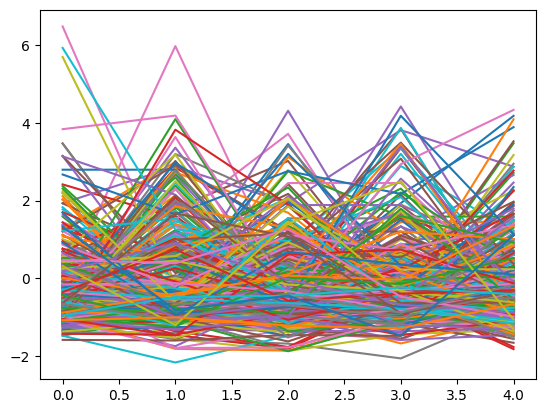

In [37]:
plt.plot(data[0][1]['neural_features'][1][:5])
plt.show()

## Baseline Approach: nejm-brain-to-text

The baseline model provided in the `nejm-brain-to-text` repository is a **Recurrent Neural Network (RNN)** designed to decode speech from neural activity. Here is a summary of the approach:

### Model Architecture
*   **Input Layer**: Day-specific linear input layers ($512 \times 512$) with **Softsign** activation. This handles non-stationarities in neural recordings across different days.
*   **Recurrent Layers**: A 5-layer **Gated Recurrent Unit (GRU)** network with 768 hidden units per layer.
*   **Output Layer**: A linear projection to phoneme probabilities.

### Training Strategy
*   **Objective**: The model is trained to predict phoneme sequences from neural features using **CTC (Connectionist Temporal Classification) Loss**.
*   **Optimizer**: **AdamW** optimizer.
*   **Data Augmentation**: To improve robustness, the training data is augmented with:
    *   **White Noise**: Added to the neural features.
    *   **Temporal Jitter**: Randomly shifting the neural data in time.
*   **Input Features**: 512 neural features (threshold crossings and spike band power from 256 electrodes), binned at 20 ms resolution.

### Decoding & Inference
*   The RNN outputs **phoneme logits**.
*   These logits are passed to an **n-gram Language Model** (e.g., 3-gram or 5-gram) to decode the most likely sequence of words.
*   The decoding process involves beam search and optional rescoring.

## Model Implementation

Below is the PyTorch implementation of the `GRUDecoder` used in the baseline. It includes:
- **Day-specific input layers** to handle session variability.
- A **multi-layer GRU** backbone.
- An optional **"patching" mechanism** (stacking time steps) to increase the effective context window.

In [38]:
import torch
from torch import nn

class GRUDecoder(nn.Module):
    '''
    Defines the GRU decoder

    This class combines day-specific input layers, a GRU, and an output classification layer
    '''
    def __init__(self,
                 neural_dim,
                 n_units,
                 n_days,
                 n_classes,
                 rnn_dropout = 0.0,
                 input_dropout = 0.0,
                 n_layers = 5, 
                 patch_size = 0,
                 patch_stride = 0,
                 ):
        '''
        neural_dim  (int)      - number of channels in a single timestep (e.g. 512)
        n_units     (int)      - number of hidden units in each recurrent layer - equal to the size of the hidden state
        n_days      (int)      - number of days in the dataset
        n_classes   (int)      - number of classes 
        rnn_dropout    (float) - percentage of units to droupout during training
        input_dropout (float)  - percentage of input units to dropout during training
        n_layers    (int)      - number of recurrent layers 
        patch_size  (int)      - the number of timesteps to concat on initial input layer - a value of 0 will disable this "input concat" step 
        patch_stride(int)      - the number of timesteps to stride over when concatenating initial input 
        '''
        super(GRUDecoder, self).__init__()
        
        self.neural_dim = neural_dim
        self.n_units = n_units
        self.n_classes = n_classes
        self.n_layers = n_layers 
        self.n_days = n_days

        self.rnn_dropout = rnn_dropout
        self.input_dropout = input_dropout
        
        self.patch_size = patch_size
        self.patch_stride = patch_stride

        # Parameters for the day-specific input layers
        self.day_layer_activation = nn.Softsign() # basically a shallower tanh 

        # Set weights for day layers to be identity matrices so the model can learn its own day-specific transformations
        self.day_weights = nn.ParameterList(
            [nn.Parameter(torch.eye(self.neural_dim)) for _ in range(self.n_days)]
        )
        self.day_biases = nn.ParameterList(
            [nn.Parameter(torch.zeros(1, self.neural_dim)) for _ in range(self.n_days)]
        )

        self.day_layer_dropout = nn.Dropout(input_dropout)
        
        self.input_size = self.neural_dim

        # If we are using "strided inputs", then the input size of the first recurrent layer will actually be in_size * patch_size
        if self.patch_size > 0:
            self.input_size *= self.patch_size

        self.gru = nn.GRU(
            input_size = self.input_size,
            hidden_size = self.n_units,
            num_layers = self.n_layers,
            dropout = self.rnn_dropout, 
            batch_first = True, # The first dim of our input is the batch dim
            bidirectional = False,
        )

        # Set recurrent units to have orthogonal param init and input layers to have xavier init
        for name, param in self.gru.named_parameters():
            if "weight_hh" in name:
                nn.init.orthogonal_(param)
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param)

        # Prediciton head. Weight init to xavier
        self.out = nn.Linear(self.n_units, self.n_classes)
        nn.init.xavier_uniform_(self.out.weight)

        # Learnable initial hidden states
        self.h0 = nn.Parameter(nn.init.xavier_uniform_(torch.zeros(1, 1, self.n_units)))

    def forward(self, x, day_idx, states = None, return_state = False):
        '''
        x        (tensor)  - batch of examples (trials) of shape: (batch_size, time_series_length, neural_dim)
        day_idx  (tensor)  - tensor which is a list of day indexs corresponding to the day of each example in the batch x. 
        '''

        # Apply day-specific layer to (hopefully) project neural data from the different days to the same latent space
        day_weights = torch.stack([self.day_weights[i] for i in day_idx], dim=0)
        day_biases = torch.cat([self.day_biases[i] for i in day_idx], dim=0).unsqueeze(1)

        x = torch.einsum("btd,bdk->btk", x, day_weights) + day_biases
        x = self.day_layer_activation(x)

        # Apply dropout to the ouput of the day specific layer
        if self.input_dropout > 0:
            x = self.day_layer_dropout(x)

        # (Optionally) Perform input concat operation
        if self.patch_size > 0: 
  
            x = x.unsqueeze(1)                      # [batches, 1, timesteps, feature_dim]
            x = x.permute(0, 3, 1, 2)               # [batches, feature_dim, 1, timesteps]
            
            # Extract patches using unfold (sliding window)
            x_unfold = x.unfold(3, self.patch_size, self.patch_stride)  # [batches, feature_dim, 1, num_patches, patch_size]
            
            # Remove dummy height dimension and rearrange dimensions
            x_unfold = x_unfold.squeeze(2)           # [batches, feature_dum, num_patches, patch_size]
            x_unfold = x_unfold.permute(0, 2, 3, 1)  # [batches, num_patches, patch_size, feature_dim]

            # Flatten last two dimensions (patch_size and features)
            x = x_unfold.reshape(x.size(0), x_unfold.size(1), -1) 
        
        # Determine initial hidden states
        if states is None:
            states = self.h0.expand(self.n_layers, x.shape[0], self.n_units).contiguous()

        # Pass input through RNN 
        output, hidden_states = self.gru(x, states)

        # Compute logits
        logits = self.out(output)
        
        if return_state:
            return logits, hidden_states
        
        return logits

In [50]:
# Example instantiation based on baseline hyperparameters
model = GRUDecoder(
    neural_dim=512,
    n_units=768,
    n_days=len(data), # Assuming 'sessions' list is available from previous cells
    n_classes=41,         # 41 classes (phonemes + blank/silence)
    rnn_dropout=0.4,
    input_dropout=0.2,
    n_layers=5,
    patch_size=14,
    patch_stride=4
)

model_cpu = GRUDecoder(
    neural_dim=512,
    n_units=256,
    n_days=len(data), # Assuming 'sessions' list is available from previous cells
    n_classes=41,         # 41 classes (phonemes + blank/silence)
    rnn_dropout=0.4,
    input_dropout=0.2,
    n_layers=2,
    patch_size=14,
    patch_stride=4
)

print(model)
# summary(model, input_size=(2, 100, 512), batch_size=2, device='cpu')

GRUDecoder(
  (day_layer_activation): Softsign()
  (day_weights): ParameterList(
      (0): Parameter containing: [torch.float32 of size 512x512]
      (1): Parameter containing: [torch.float32 of size 512x512]
      (2): Parameter containing: [torch.float32 of size 512x512]
      (3): Parameter containing: [torch.float32 of size 512x512]
      (4): Parameter containing: [torch.float32 of size 512x512]
      (5): Parameter containing: [torch.float32 of size 512x512]
      (6): Parameter containing: [torch.float32 of size 512x512]
      (7): Parameter containing: [torch.float32 of size 512x512]
      (8): Parameter containing: [torch.float32 of size 512x512]
      (9): Parameter containing: [torch.float32 of size 512x512]
      (10): Parameter containing: [torch.float32 of size 512x512]
      (11): Parameter containing: [torch.float32 of size 512x512]
      (12): Parameter containing: [torch.float32 of size 512x512]
      (13): Parameter containing: [torch.float32 of size 512x512]
     

## Running Inference with Loaded Data

To use the model with the loaded data, you need to:
1.  **Select a trial**: Extract the `neural_features` for a specific trial.
2.  **Format the input**: Convert the numpy array to a PyTorch tensor and add a batch dimension (shape: `[1, time_steps, 512]`).
3.  **Prepare `day_idx`**: Create a tensor containing the session index for the trial (shape: `[1]`).
4.  **Pass to model**: Call the model with the input and day index.

Note: Since the model is initialized with random weights, the output logits will be random. To get meaningful predictions, you would need to load the pretrained weights.

In [40]:
# 1. Select a trial (e.g., first session, first file, first trial)
session_idx = 0
file_idx = 0 # Usually 0=train, 1=test, 2=val depending on sorting, check data[session_idx][file_idx].keys() if unsure
trial_idx = 0

# Get neural features: shape (time_steps, 512)
features_numpy = data[session_idx][file_idx]['neural_features'][trial_idx]

# 2. Format input
# Convert to tensor and add batch dimension -> (1, time_steps, 512)
x = torch.tensor(features_numpy, dtype=torch.float32).unsqueeze(0)

# 3. Prepare day_idx
# The model needs to know which day/session this data belongs to for the day-specific layer
day_idx = torch.tensor([session_idx], dtype=torch.long)

# 4. Run the model
model.eval() # Set to evaluation mode
with torch.no_grad():
    logits = model(x, day_idx)

print(f"Input shape: {x.shape}")
print(f"Output logits shape: {logits.shape}") # Should be (1, output_time_steps, n_classes)
print("Inference successful!")

Input shape: torch.Size([1, 936, 512])
Output logits shape: torch.Size([1, 231, 41])
Inference successful!


## Training Loop Example

Here is a cell that demonstrates how to train the model on a few examples from the loaded data.
It defines the **CTC Loss**, the **Optimizer**, and runs a training step.

In [51]:
import torch.optim as optim
import random

# --- Hyperparameters ---
learning_rate = 1e-4
n_epochs = 3           # <--- Reduced for debugging speed
weight_decay = 1e-2
noise_std = 0.2        
max_sessions = 1       # <--- Train on ONLY 1 session for speed
max_val_trials = 10    # <--- Validate on ONLY 10 trials

# --- Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cpu':
    print("Warning: Training on CPU with this model size (5 layers, 768 units) will be slow.")
    model = model_cpu

# --- Setup ---
model.to(device)
ctc_loss = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=False)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

train_losses = []
val_losses = []

print(f"Starting training on {min(len(data), max_sessions)} sessions...")

for epoch in range(n_epochs):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    train_batches = 0
    
    for session_idx, session_data in enumerate(data):
        if session_idx >= max_sessions: break

        if len(session_data) < 3: continue
        train_data = session_data[1] 
        num_trials = len(train_data['neural_features'])
        
        trial_indices = list(range(num_trials))
        random.shuffle(trial_indices)
        
        for i in trial_indices:
            features = train_data['neural_features'][i]
            targets = train_data['seq_class_ids'][i]
            target_len = train_data['seq_len'][i]
            n_time_steps = features.shape[0]
            
            # Validation checks
            if targets is None or target_len > len(targets): continue
            
            # Trim targets and check for blank token
            targets = targets[:target_len]
            if 0 in targets: continue 

            # --- Data Augmentation ---
            features_tensor = torch.tensor(features, dtype=torch.float32)
            # Add Gaussian Noise
            features_tensor = features_tensor + torch.randn_like(features_tensor) * noise_std
            
            # Prepare Inputs and move to Device
            x = features_tensor.unsqueeze(0).to(device)
            day_idx = torch.tensor([session_idx], dtype=torch.long).to(device)
            y = torch.tensor(targets, dtype=torch.long).to(device)
            
            # Calculate input lengths (accounting for patching)
            patch_size = 14
            patch_stride = 4
            input_len_val = int((n_time_steps - patch_size) / patch_stride + 1)
            
            if input_len_val < target_len: continue

            input_lengths = torch.tensor([input_len_val], dtype=torch.long)
            target_lengths = torch.tensor([target_len], dtype=torch.long)

            # Optimization
            optimizer.zero_grad()
            logits = model(x, day_idx)
            log_probs = logits.log_softmax(2).permute(1, 0, 2)
            
            try:
                loss = ctc_loss(log_probs, y, input_lengths, target_lengths)
                if not torch.isnan(loss) and not torch.isinf(loss):
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
                    optimizer.step()
                    
                    total_train_loss += loss.item()
                    train_batches += 1
                    
                    # Progress print
                    if train_batches % 10 == 0:
                        print(f"  Epoch {epoch+1} | Batch {train_batches}/{num_trials} | Loss: {loss.item():.4f}", end='\r')
            except Exception:
                continue
    
    print() # Newline after progress bar
    avg_train_loss = total_train_loss / train_batches if train_batches > 0 else 0
    train_losses.append(avg_train_loss)
    
    # --- VALIDATION PHASE ---
    model.eval()
    total_val_loss = 0
    val_batches = 0
    
    with torch.no_grad():
        for session_idx, session_data in enumerate(data):
            if session_idx >= max_sessions: break 

            if len(session_data) < 3: continue
            val_data = session_data[2] 
            
            num_trials = len(val_data['neural_features'])
            val_indices = list(range(num_trials))
            if num_trials > max_val_trials:
                val_indices = random.sample(val_indices, max_val_trials)
            
            for i in val_indices:
                features = val_data['neural_features'][i]
                targets = val_data['seq_class_ids'][i]
                target_len = val_data['seq_len'][i]
                n_time_steps = features.shape[0]
                
                if targets is None or target_len > len(targets): continue
                targets = targets[:target_len]
                if 0 in targets: continue

                x = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(device)
                day_idx = torch.tensor([session_idx], dtype=torch.long).to(device)
                y = torch.tensor(targets, dtype=torch.long).to(device)
                
                input_len_val = int((n_time_steps - patch_size) / patch_stride + 1)
                if input_len_val < target_len: continue

                input_lengths = torch.tensor([input_len_val], dtype=torch.long)
                target_lengths = torch.tensor([target_len], dtype=torch.long)
                
                logits = model(x, day_idx)
                log_probs = logits.log_softmax(2).permute(1, 0, 2)
                
                try:
                    loss = ctc_loss(log_probs, y, input_lengths, target_lengths)
                    total_val_loss += loss.item()
                    val_batches += 1
                except: continue

    avg_val_loss = total_val_loss / val_batches if val_batches > 0 else 0
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

print("Training complete.")

Using device: cpu
Starting training on 1 sessions...
  Epoch 1 | Batch 340/348 | Loss: 2.9758
Epoch 1/3 | Train Loss: 3.8996 | Val Loss: 4.1541
  Epoch 2 | Batch 340/348 | Loss: 2.7530
Epoch 2/3 | Train Loss: 2.9156 | Val Loss: 3.0327
  Epoch 3 | Batch 340/348 | Loss: 2.1673
Epoch 3/3 | Train Loss: 2.4216 | Val Loss: 2.7756
Training complete.


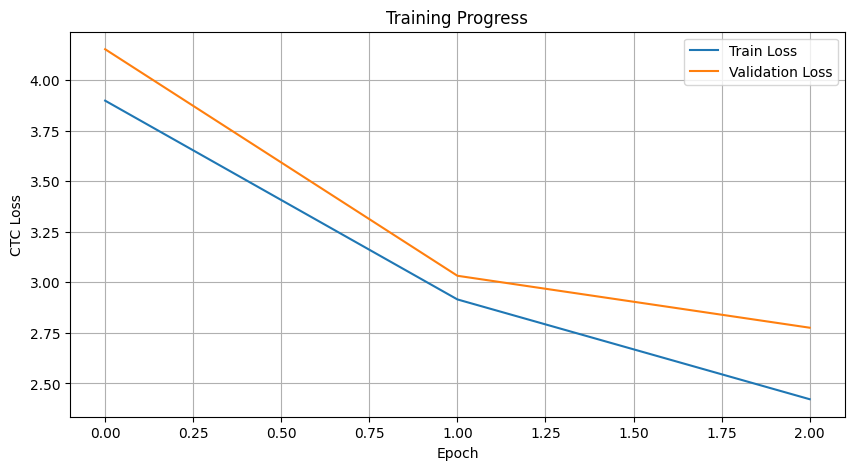

In [52]:
# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('CTC Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True)
plt.show()